In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Play-by-Play.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully loaded /content/drive/MyDrive/Play-by-Play.csv


,match_id,point_id,video_time,team,player_number,player_name,player_id,skill_type,evaluation_code,evaluation,...,team_id,point_won_by,winning_attack,serving_team,phase,home_score,visiting_score,set_player_id,reception_quality,point_differential
0,720eb12d9c14f08143b2262e57afe29b,0,476,Eastern Washington University,NaN,NaN,NaN,NaN,NaN,NaN,...,73.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
1,720eb12d9c14f08143b2262e57afe29b,0,476,Eastern Washington University,NaN,NaN,NaN,NaN,NaN,NaN,...,73.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
2,720eb12d9c14f08143b2262e57afe29b,0,476,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
3,720eb12d9c14f08143b2262e57afe29b,0,476,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
4,720eb12d9c14f08143b2262e57afe29b,0,476,Eastern Washington University,15.0,Anna Bolich,-512271.0,Jump-float serve,/,"Positive, no attack",...,73.0,"University of California, San Diego",f,Eastern Washington University,Serve,0,0,NaN,"Poor, no attack",0


In [ ]:
UCSD_ID = 1378
SOURCE_FILE = '/content/drive/MyDrive/Play-by-Play.csv'

ATTACK_MAPPING = {
    'X6': 'Front', 'X5': 'Front', 'V5': 'Front', 'X9': 'Front', 'X0': 'Front', 'V0': 'Front',
    'XM': 'Middle', 'X1': 'Middle', 'X2': 'Middle', 'XR': 'Middle', 'XB': 'Middle', 'X7': 'Middle', 'X3': 'Middle',
    'X8': 'Back', 'V8': 'Back', 'XO': 'Back', 'XS': 'Back', 'CF': 'Back', 'CB': 'Back',
    'VP': 'Pipe', 'XP': 'Pipe'
}

### Filter for UCSD

In [ ]:
df = pd.read_csv(SOURCE_FILE)
df_ucsd = df[df['team_id'] == UCSD_ID].copy()
display(df_ucsd.head())

,match_id,point_id,video_time,team,player_number,player_name,player_id,skill_type,evaluation_code,evaluation,...,team_id,point_won_by,winning_attack,serving_team,phase,home_score,visiting_score,set_player_id,reception_quality,point_differential
2,720eb12d9c14f08143b2262e57afe29b,0,476,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
3,720eb12d9c14f08143b2262e57afe29b,0,476,"University of California, San Diego",NaN,NaN,NaN,NaN,NaN,NaN,...,1378.0,"University of California, San Diego",f,Eastern Washington University,NaN,0,0,NaN,"Poor, no attack",0
5,720eb12d9c14f08143b2262e57afe29b,0,477,"University of California, San Diego",2.0,Ireland McNees,-552416.0,Jump-float serve reception,/,"Poor, no attack",...,1378.0,"University of California, San Diego",f,Eastern Washington University,Reception,0,0,NaN,"Poor, no attack",0
7,720eb12d9c14f08143b2262e57afe29b,0,479,"University of California, San Diego",2.0,Ireland McNees,-552416.0,Other dig,+,Good dig,...,1378.0,"University of California, San Diego",f,Eastern Washington University,Transition,0,0,NaN,"Poor, no attack",0
8,720eb12d9c14f08143b2262e57afe29b,0,480,"University of California, San Diego",6.0,Molly McCluskey,-513914.0,High ball set,#,Perfect,...,1378.0,"University of California, San Diego",f,Eastern Washington University,Transition,0,0,NaN,"Poor, no attack",0


In [ ]:
receptions = df_ucsd[(df_ucsd['skill_type'].str.contains('reception', na=False, case=False)) & (df_ucsd['evaluation_code'].isin(['#', '+']))]
display(receptions.head())

,match_id,point_id,video_time,team,player_number,player_name,player_id,skill_type,evaluation_code,evaluation,...,team_id,point_won_by,winning_attack,serving_team,phase,home_score,visiting_score,set_player_id,reception_quality,point_differential
69,720eb12d9c14f08143b2262e57afe29b,6,644,"University of California, San Diego",2.0,Ireland McNees,-552416.0,Jump-float serve reception,+,"Positive, attack",...,1378.0,"University of California, San Diego",f,Eastern Washington University,Reception,4,2,NaN,"Positive, attack",2
240,720eb12d9c14f08143b2262e57afe29b,18,1102,"University of California, San Diego",16.0,Maria Fernanda Afonso,-552422.0,Jump-float serve reception,+,"Positive, attack",...,1378.0,"University of California, San Diego",f,Eastern Washington University,Reception,12,6,NaN,"Positive, attack",6
311,720eb12d9c14f08143b2262e57afe29b,24,1359,"University of California, San Diego",12.0,Kayla Uhlick,-381007.0,Jump-float serve reception,+,"Positive, attack",...,1378.0,Eastern Washington University,f,Eastern Washington University,Reception,17,7,NaN,"Positive, attack",10
321,720eb12d9c14f08143b2262e57afe29b,25,1383,"University of California, San Diego",12.0,Kayla Uhlick,-381007.0,Jump-float serve reception,+,"Positive, attack",...,1378.0,"University of California, San Diego",f,Eastern Washington University,Reception,17,8,NaN,"Positive, attack",9
446,720eb12d9c14f08143b2262e57afe29b,34,1678,"University of California, San Diego",9.0,Paulina Baillie,-513911.0,Jump-float serve reception,+,"Positive, attack",...,1378.0,"University of California, San Diego",f,Eastern Washington University,Reception,23,11,NaN,"Positive, attack",12


### FSBO plays

In [ ]:
fbso_plays = []
grouped = df_ucsd.groupby(['match_id', 'point_id'])

for _, rec in receptions.iterrows():
    try:
        point_df = grouped.get_group((rec['match_id'], rec['point_id']))
        attacks = point_df[(point_df['skill_type'].str.contains('attack', na=False, case=False)) & (point_df['phase'] == 'Reception')]
        if not attacks.empty:
            first_attack = attacks.iloc[0]
            cat = ATTACK_MAPPING.get(first_attack['attack_code'], 'Other')
            if cat != 'Other':
                is_home = (rec['home_team_id'] == UCSD_ID)
                fbso_plays.append({
                    'match_id': rec['match_id'], 'set_number': rec['set_number'], 'point_id': rec['point_id'],
                    'score_diff': rec['point_differential'], 'setter_position': rec['home_setter_position'] if is_home else rec['visiting_setter_position'],
                    'setter_id': first_attack['set_player_id'], 'reception_quality': rec['evaluation_code'], 'target_attack': cat
                })
    except: continue

fbso_df = pd.DataFrame(fbso_plays).sort_values(['match_id', 'set_number', 'point_id']).reset_index(drop=True)
print(f"Initial FBSO Plays extracted: {len(fbso_df)}")
display(fbso_df.head())

Initial FBSO Plays extracted: 690


,match_id,set_number,point_id,score_diff,setter_position,setter_id,reception_quality,target_attack
0,01ff8dab997fc5fe1041f1a821bb1682,1,5,1,6.0,-552418.0,+,Front
1,01ff8dab997fc5fe1041f1a821bb1682,1,7,3,6.0,-552418.0,+,Middle
2,01ff8dab997fc5fe1041f1a821bb1682,1,27,-1,1.0,-552418.0,+,Front
3,01ff8dab997fc5fe1041f1a821bb1682,1,29,-1,6.0,-552418.0,+,Front
4,01ff8dab997fc5fe1041f1a821bb1682,1,37,-3,5.0,-552418.0,#,Front


### Sliding window of previous attacks and also same attacks


In [ ]:
def add_memory(group):
    for i in range(1, 6): group[f'prev_{i}'] = group['target_attack'].shift(i).fillna('None')
    group['consecutive_same'] = 0
    current_streak = 0
    for idx in range(1, len(group)):
        if group.iloc[idx]['target_attack'] == group.iloc[idx-1]['target_attack']: current_streak += 1
        else: current_streak = 0
        group.iloc[idx, group.columns.get_loc('consecutive_same')] = current_streak
    return group
# just adds sliding window to each group with a streak
fbso_v3 = fbso_df.groupby('match_id', group_keys=False).apply(add_memory)
fbso_v3['setter_id'] = fbso_v3['setter_id'].fillna(-1.0)

print(f"Final Data Prepared. Plays extracted: {len(fbso_v3)}")
display(fbso_v3.head())

Final Data Prepared. Plays extracted: 690


/tmp/ipykernel_16069/1465189659.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fbso_v3 = fbso_df.groupby('match_id', group_keys=False).apply(add_memory)


,match_id,set_number,point_id,score_diff,setter_position,setter_id,reception_quality,target_attack,prev_1,prev_2,prev_3,prev_4,prev_5,consecutive_same
0,01ff8dab997fc5fe1041f1a821bb1682,1,5,1,6.0,-552418.0,+,Front,None,None,None,None,None,0
1,01ff8dab997fc5fe1041f1a821bb1682,1,7,3,6.0,-552418.0,+,Middle,Front,None,None,None,None,0
2,01ff8dab997fc5fe1041f1a821bb1682,1,27,-1,1.0,-552418.0,+,Front,Middle,Front,None,None,None,0
3,01ff8dab997fc5fe1041f1a821bb1682,1,29,-1,6.0,-552418.0,+,Front,Front,Middle,Front,None,None,1
4,01ff8dab997fc5fe1041f1a821bb1682,1,37,-3,5.0,-552418.0,#,Front,Front,Front,Middle,Front,None,2


In [ ]:
categorical_cols = ['prev_1', 'prev_2', 'prev_3', 'prev_4', 'prev_5', 'setter_id', 'reception_quality']
numeric_cols = ['score_diff', 'setter_position', 'consecutive_same', 'set_number']

for col in categorical_cols:
  fbso_v3[col] = LabelEncoder().fit_transform(fbso_v3[col].astype(str))
le_target = LabelEncoder()
y = le_target.fit_transform(fbso_v3['target_attack']) #encoding the y
X = fbso_v3[numeric_cols + categorical_cols] #list appension for X features

### Exploratory Data Analysis (EDA)

#### 1. Initial Data Inspection

In [ ]:
print("\n--- fbso_v3 Info ---")
fbso_v3.info()
print("\n--- fbso_v3 Description ---")
display(fbso_v3.describe(include='all'))
print("\n--- Missing Values ---")
print(fbso_v3.isnull().sum())


--- fbso_v3 Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 690 entries, 0 to 689
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   match_id           690 non-null    object 
 1   set_number         690 non-null    int64  
 2   point_id           690 non-null    int64  
 3   score_diff         690 non-null    int64  
 4   setter_position    690 non-null    float64
 5   setter_id          690 non-null    int64  
 6   reception_quality  690 non-null    int64  
 7   target_attack      690 non-null    object 
 8   prev_1             690 non-null    int64  
 9   prev_2             690 non-null    int64  
 10  prev_3             690 non-null    int64  
 11  prev_4             690 non-null    int64  
 12  prev_5             690 non-null    int64  
 13  consecutive_same   690 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 80.9+ KB

--- fbso_v3 Description ---


,match_id,set_number,point_id,score_diff,setter_position,setter_id,reception_quality,target_attack,prev_1,prev_2,prev_3,prev_4,prev_5,consecutive_same
count,690,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000
unique,20,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,19dd873a34c2a1aa329a846236ee2cfe,NaN,NaN,NaN,NaN,NaN,NaN,Front,NaN,NaN,NaN,NaN,NaN,NaN
freq,49,NaN,NaN,NaN,NaN,NaN,NaN,396,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.482609,88.531884,0.691304,3.668116,0.469565,0.871014,NaN,1.143478,1.205797,1.260870,1.311594,1.362319,0.833333
std,NaN,1.196446,54.835521,4.117866,1.682747,0.499435,0.335427,NaN,0.745373,0.799834,0.847641,0.891833,0.931173,1.535186
min,NaN,1.000000,0.000000,-12.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,41.000000,-2.000000,2.000000,0.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
50%,NaN,2.000000,86.500000,0.000000,4.000000,0.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,NaN,3.000000,131.000000,3.000000,5.000000,1.000000,1.000000,NaN,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000



--- Missing Values ---
match_id             0
set_number           0
point_id             0
score_diff           0
setter_position      0
setter_id            0
reception_quality    0
target_attack        0
prev_1               0
prev_2               0
prev_3               0
prev_4               0
prev_5               0
consecutive_same     0
dtype: int64


#### 2. Target Variable Distribution (`target_attack`)

/tmp/ipykernel_16069/3752357653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fbso_v3, x='target_attack', palette='viridis')


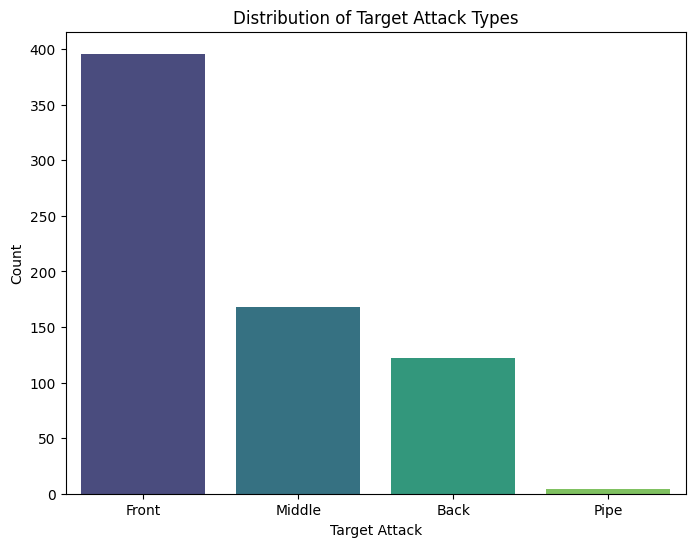

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=fbso_v3, x='target_attack', palette='viridis')
plt.title('Distribution of Target Attack Types')
plt.xlabel('Target Attack')
plt.ylabel('Count')
plt.show()

#### 3. Numerical Feature Distributions

/tmp/ipykernel_16069/366174300.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(fbso_v3[col], kde=True, bins=20, palette='magma')
/tmp/ipykernel_16069/366174300.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(fbso_v3[col], kde=True, bins=20, palette='magma')
/tmp/ipykernel_16069/366174300.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(fbso_v3[col], kde=True, bins=20, palette='magma')
/tmp/ipykernel_16069/366174300.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(fbso_v3[col], kde=True, bins=20, palette='magma')


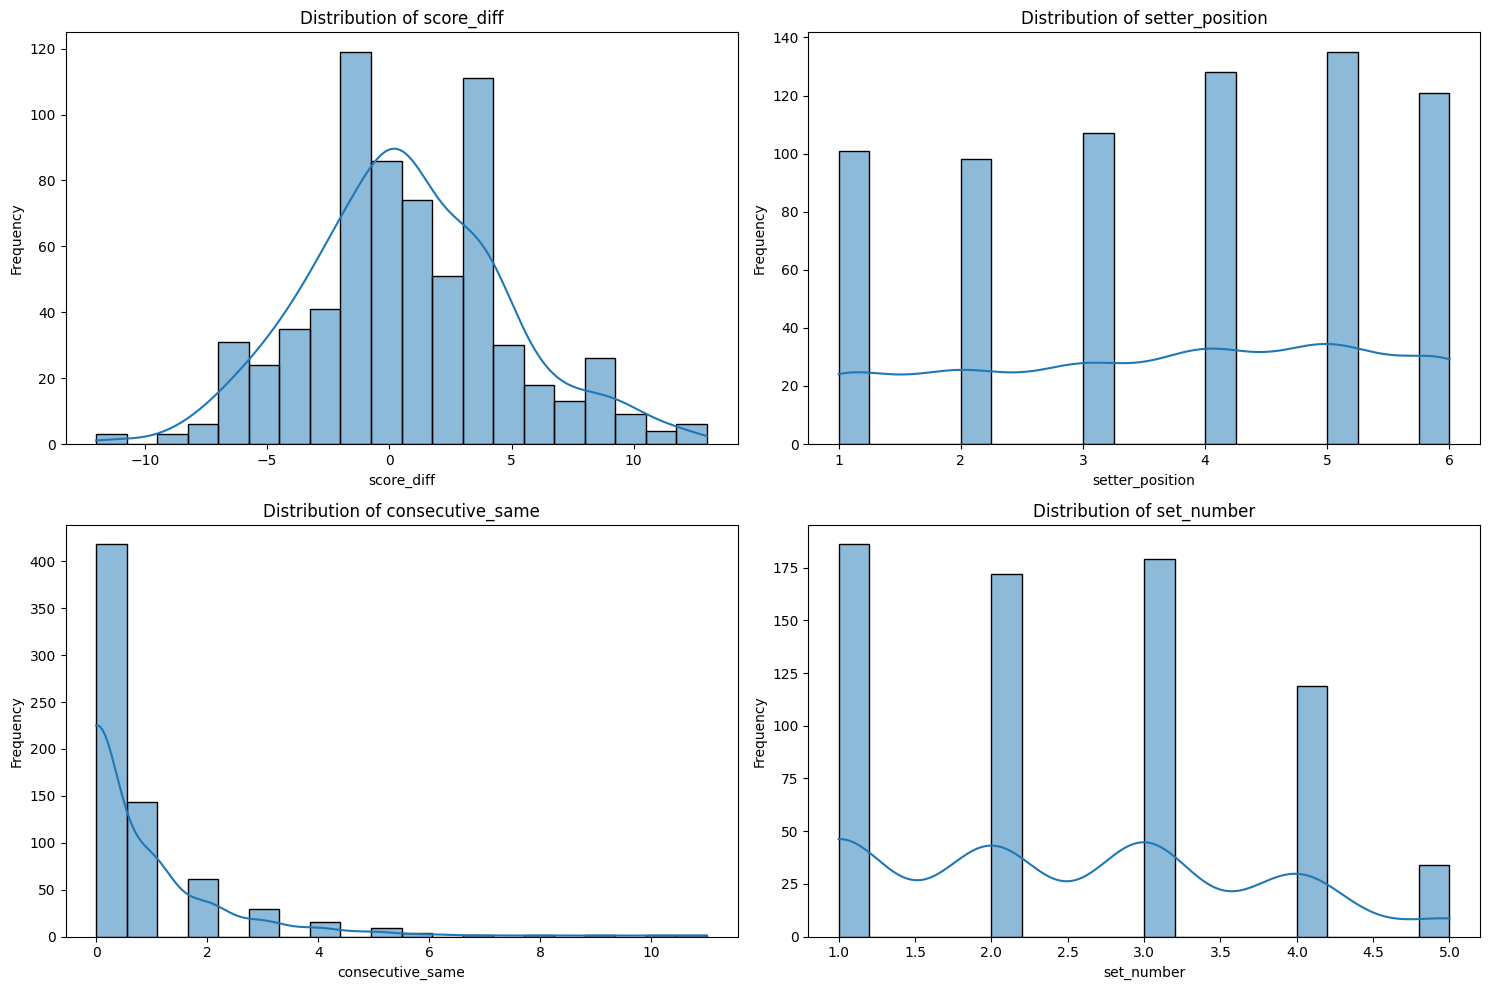

In [ ]:
numeric_cols_eda = ['score_diff', 'setter_position', 'consecutive_same', 'set_number']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_eda):
    plt.subplot(2, 2, i + 1)
    sns.histplot(fbso_v3[col], kde=True, bins=20, palette='magma')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### 4. Categorical Feature Distributions

/tmp/ipykernel_16069/2854140662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fbso_v3, x=col, palette='cividis')
/tmp/ipykernel_16069/2854140662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fbso_v3, x=col, palette='cividis')
/tmp/ipykernel_16069/2854140662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fbso_v3, x=col, palette='cividis')
/tmp/ipykernel_16069/2854140662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to

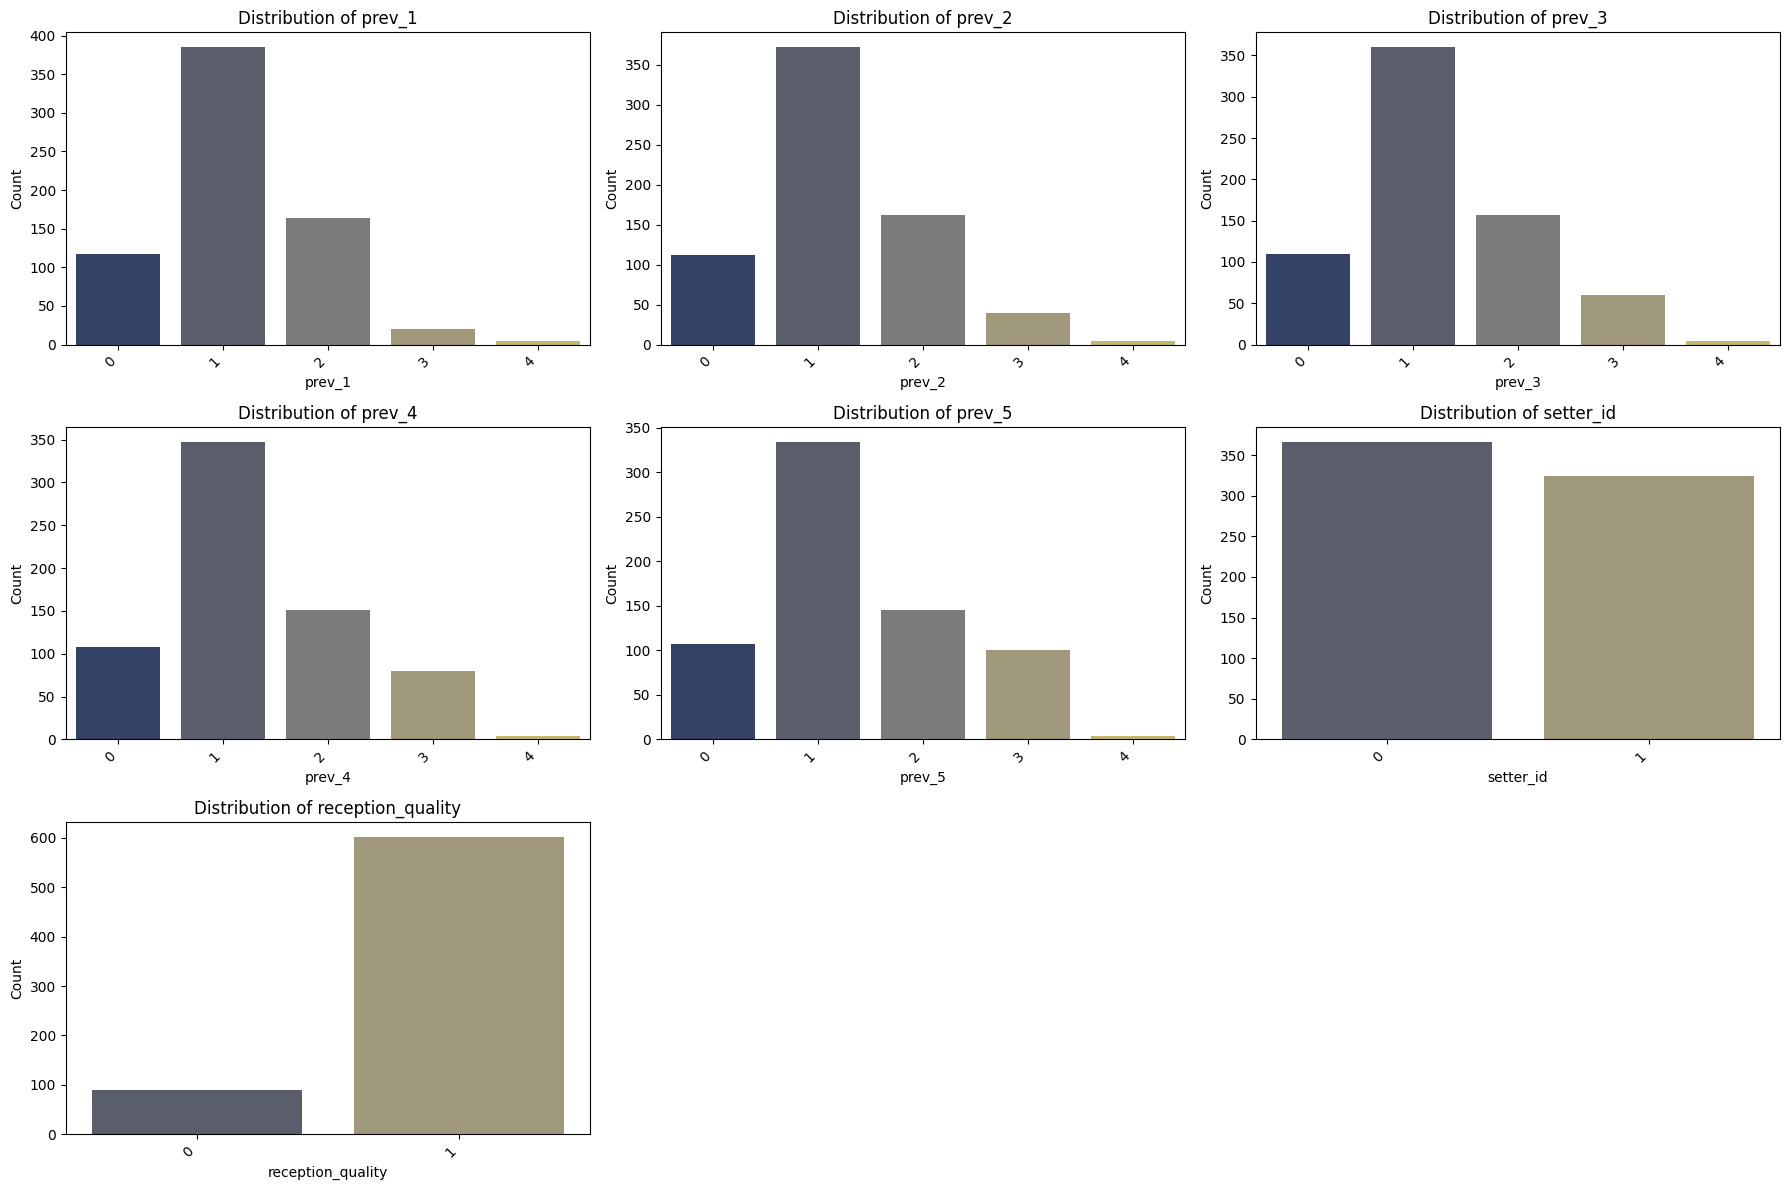

In [ ]:
categorical_cols_eda = ['prev_1', 'prev_2', 'prev_3', 'prev_4', 'prev_5', 'setter_id', 'reception_quality']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols_eda):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=fbso_v3, x=col, palette='cividis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5. Relationship between Features and Target Variable

##### Numerical Features vs. Target

/tmp/ipykernel_16069/2996323423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fbso_v3, x='target_attack', y=col, palette='viridis')
/tmp/ipykernel_16069/2996323423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fbso_v3, x='target_attack', y=col, palette='viridis')
/tmp/ipykernel_16069/2996323423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fbso_v3, x='target_attack', y=col, palette='viridis')
/tmp/ipykernel_16069/2996323423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

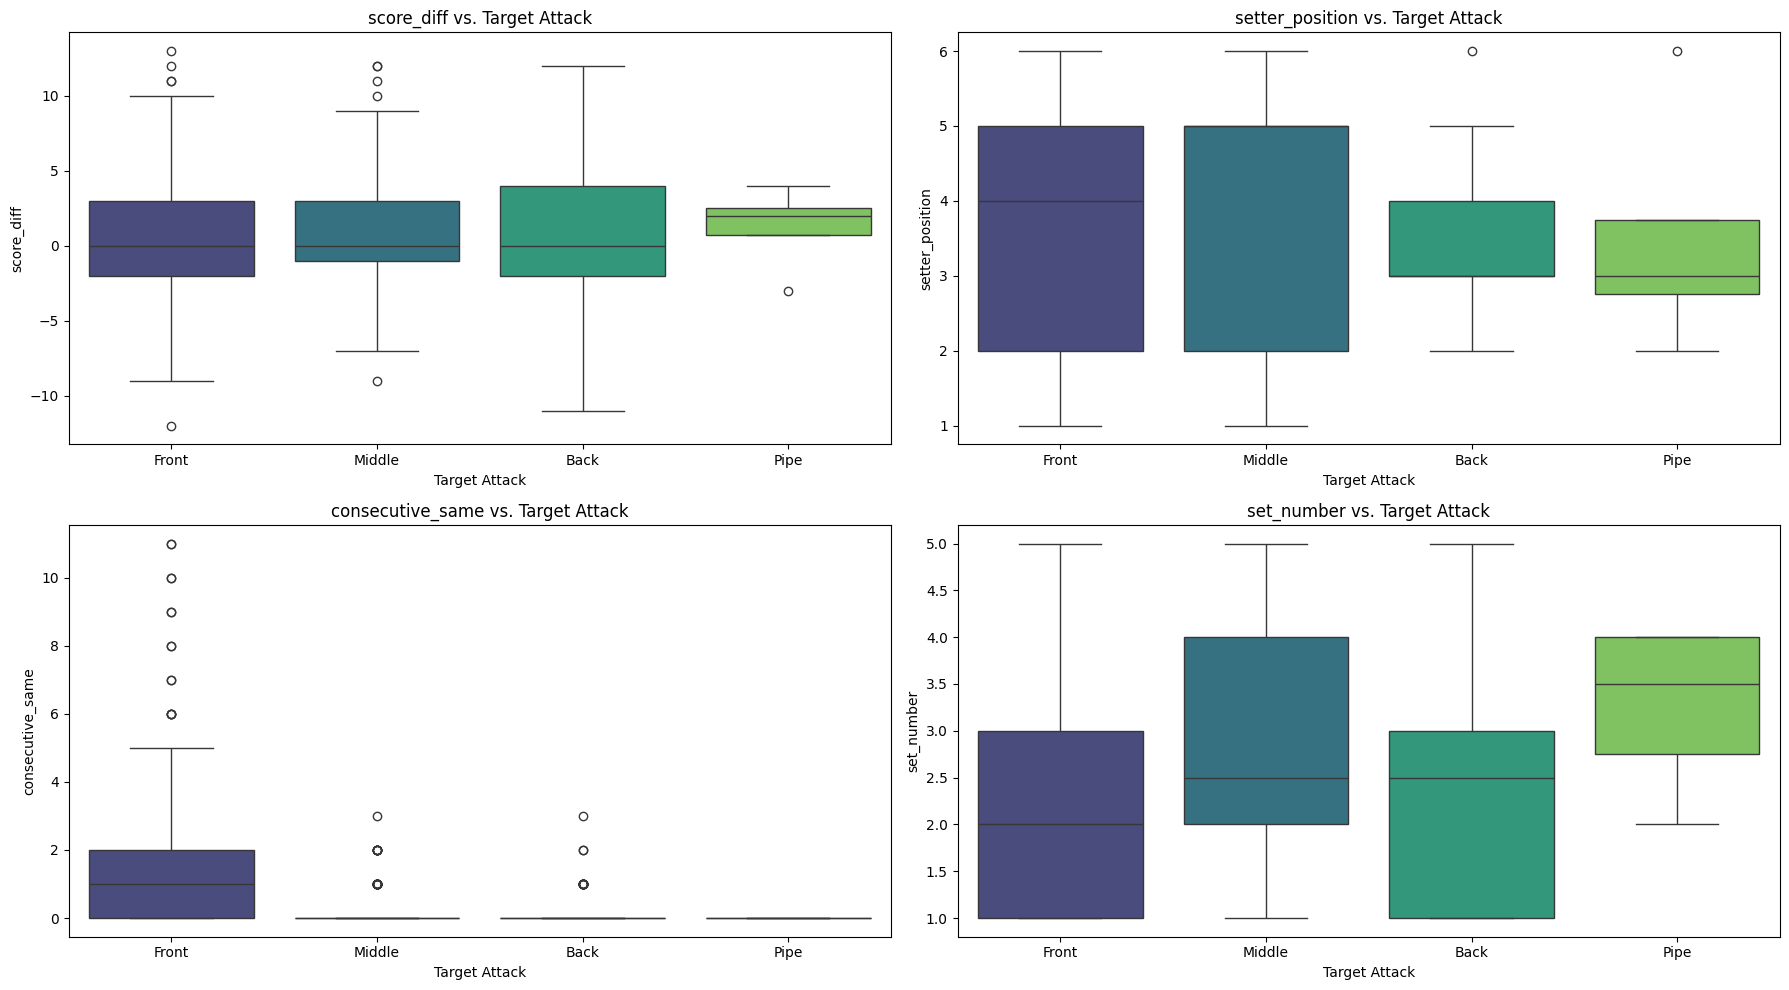

In [ ]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols_eda):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=fbso_v3, x='target_attack', y=col, palette='viridis')
    plt.title(f'{col} vs. Target Attack')
    plt.xlabel('Target Attack')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

##### Categorical Features vs. Target

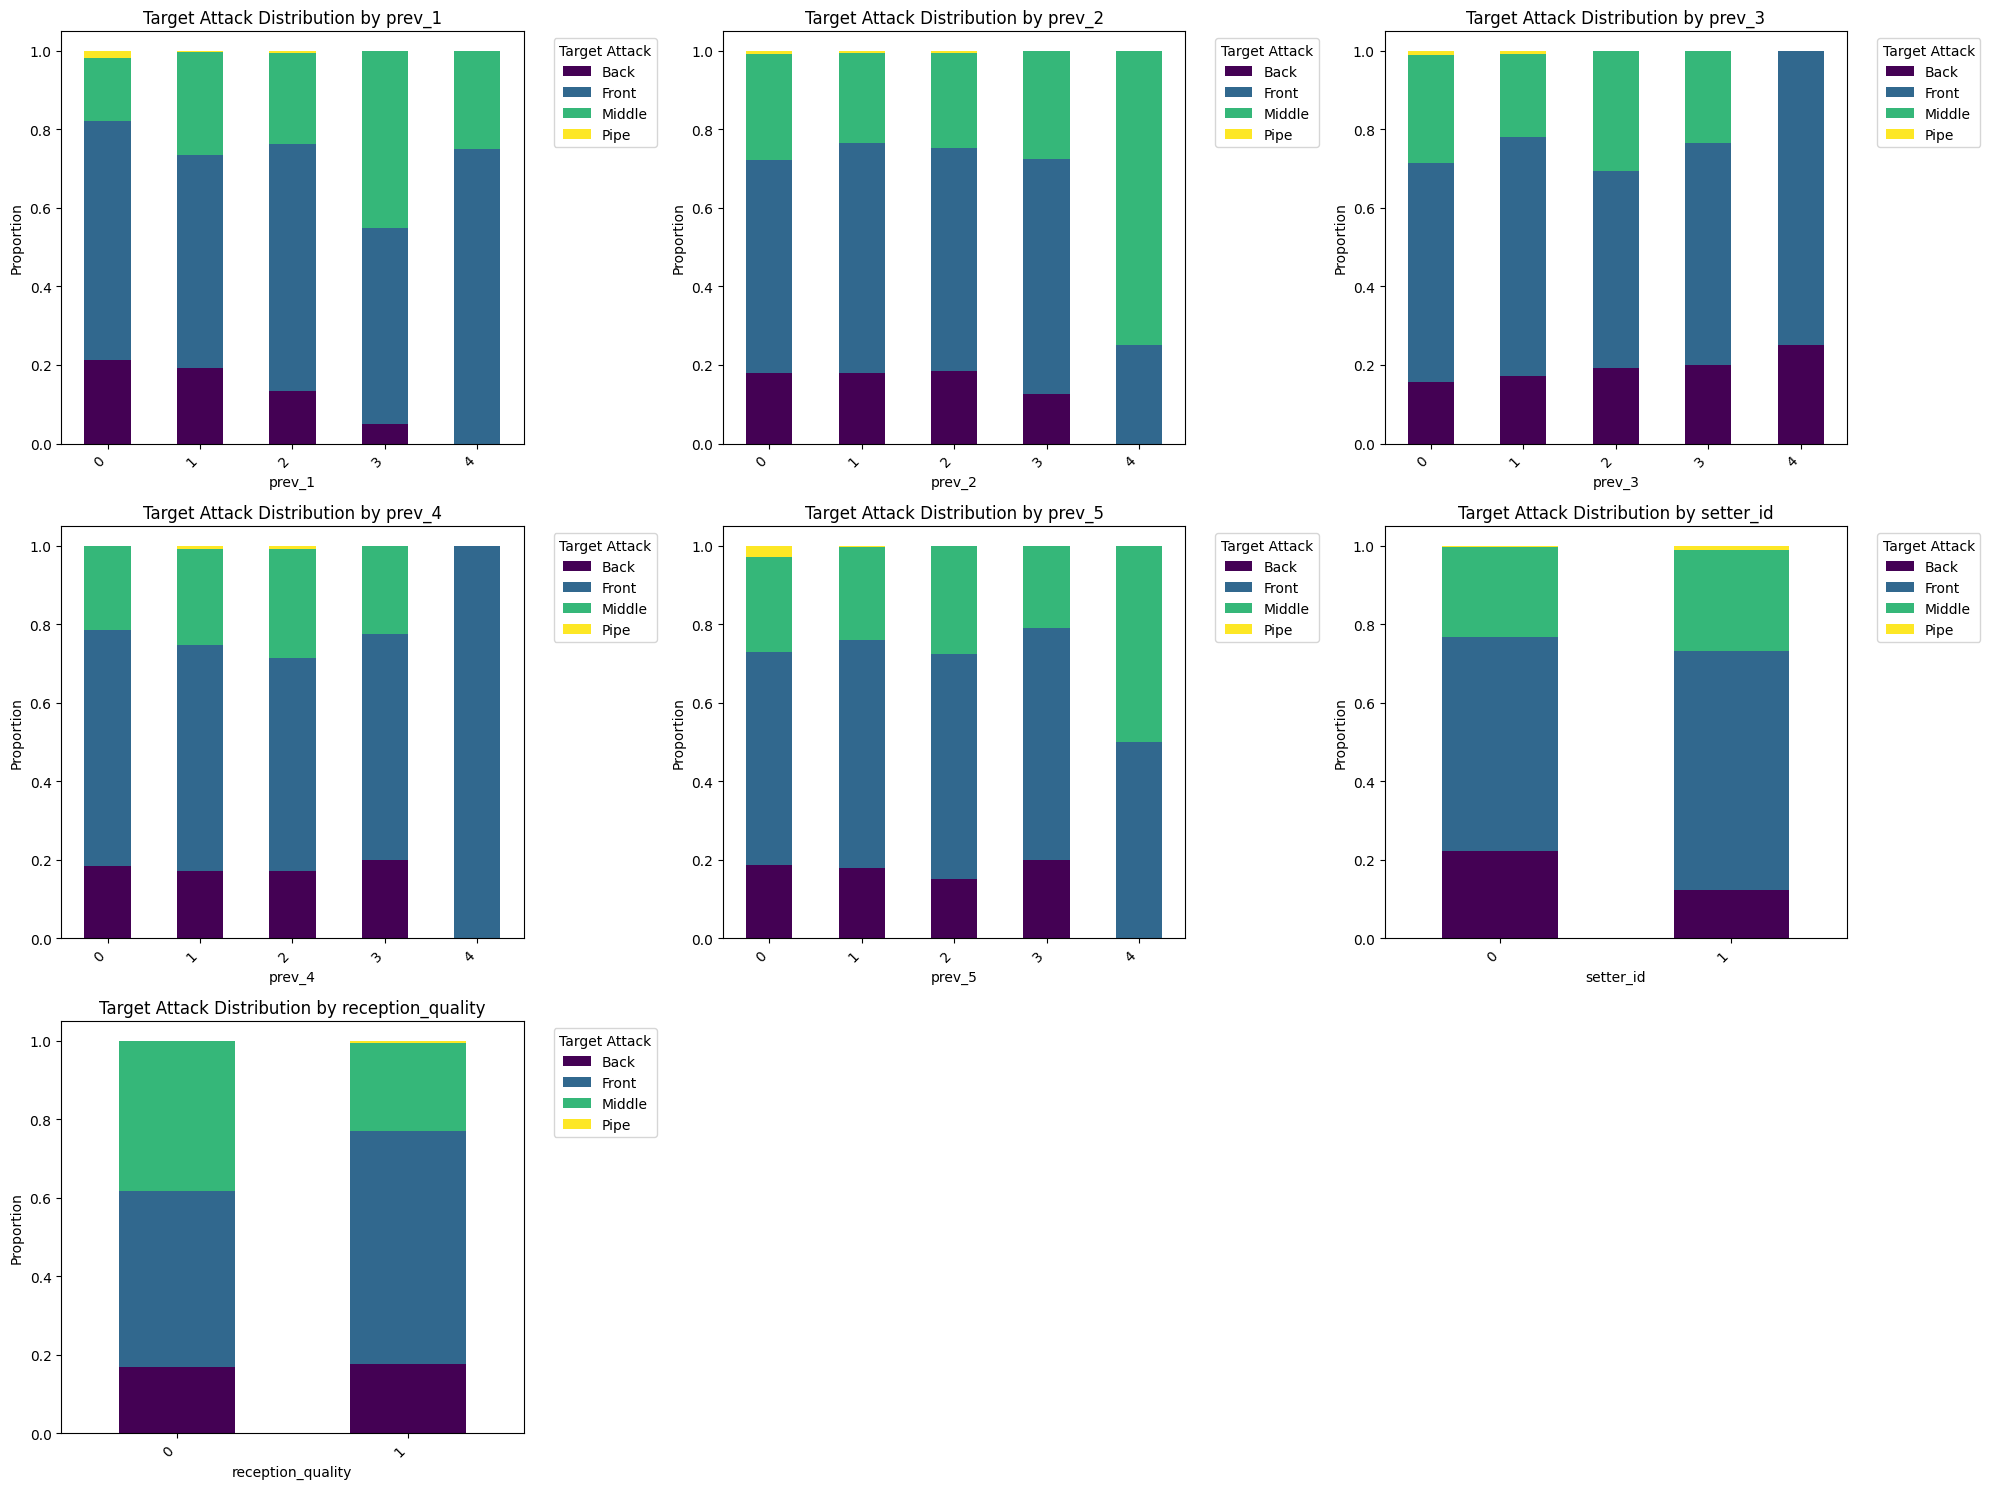

In [ ]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols_eda):
    plt.subplot(3, 3, i + 1)
    ct = pd.crosstab(fbso_v3[col], fbso_v3['target_attack'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'Target Attack Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Target Attack', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 6. Correlation Matrix for Numerical Features

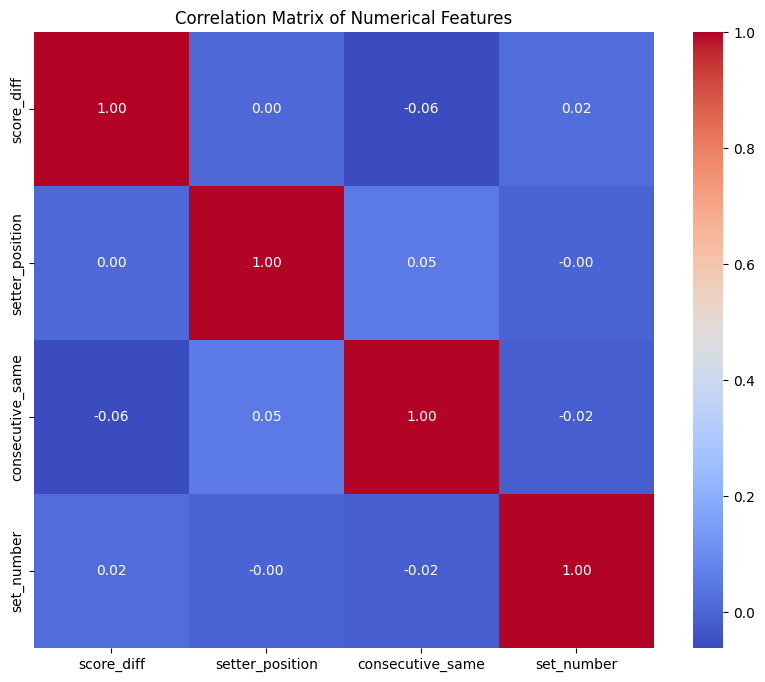

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(fbso_v3[numeric_cols_eda].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Model 1: Gradient Boosting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)



best_gb = GradientBoostingClassifier(learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8, random_state=42)
best_gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=200,
                           random_state=42, subsample=0.8)

### MODEL 2: NEURAL Net

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, n_classes))
    def forward(self, x): return self.net(x)

model = MLP(X.shape[1], len(le_target.classes_))

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_s), torch.LongTensor(y_train)), batch_size=16, shuffle=True, drop_last=True)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
for epoch in range(200):
    model.train()
    for b_x, b_y in train_loader:
        optimizer.zero_grad(); nn.CrossEntropyLoss()(model(b_x), b_y).backward(); optimizer.step()

### MODEL 3: Ensemble


In [ ]:
model.eval()
with torch.no_grad(): mlp_probs = torch.softmax(model(torch.FloatTensor(X_test_s)), dim=1).numpy()
gb_probs = best_gb.predict_proba(X_test)
ensemble_preds = np.argmax((0.6 * gb_probs) + (0.4 * mlp_probs), axis=1)
print(f"ULTIMATE MODEL ACCURACY: {accuracy_score(y_test, ensemble_preds):.1%}")

ULTIMATE MODEL ACCURACY: 87.0%



--- Final Scouting Report ---
              precision    recall  f1-score   support

        Back       0.85      0.71      0.77        24
       Front       0.89      0.99      0.93        79
      Middle       0.83      0.74      0.78        34
        Pipe       0.00      0.00      0.00         1

    accuracy                           0.87       138
   macro avg       0.64      0.61      0.62       138
weighted avg       0.86      0.87      0.86       138



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


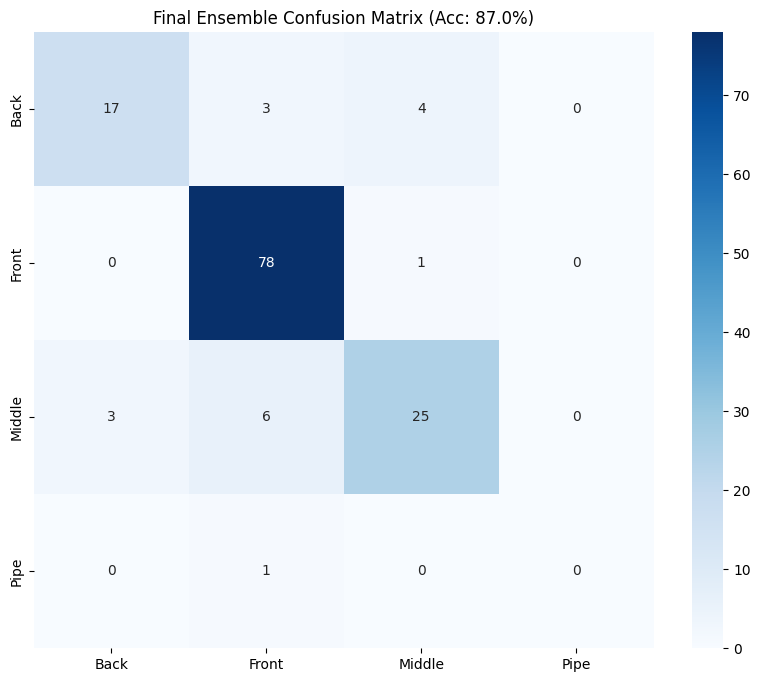

In [ ]:
print("\n--- Final Scouting Report ---")
print(classification_report(y_test, ensemble_preds, target_names=le_target.classes_))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, ensemble_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Final Ensemble Confusion Matrix (Acc: {accuracy_score(y_test, ensemble_preds):.1%})')
plt.show()